# Hormuz Cable Risk
## Coastal Infrastructure Vulnerability Index for Submarine Cable Landing Points in the Gulf Zone

This notebook documents the full analysis pipeline: data sources, methodology, results, and limitations.

**Data coverage:** 1989 – March 2026  
**Author:** Carolina Cruz  
**Repository:** [github.com/CarolinaMCruz/hormuz-cable-risk](https://github.com/CarolinaMCruz/hormuz-cable-risk)

## Abstract

This project develops a **Coastal Infrastructure Vulnerability Index** for submarine cable landing points in the Gulf zone, covering ten countries: Yemen, Pakistan, Iraq, Kuwait, Saudi Arabia, Iran, United Arab Emirates, Qatar, Bahrain, and Oman.

Using data from TeleGeography's Submarine Cable Map, the UCDP Georeferenced Event Dataset (1989–2026), and Global Fishing Watch AIS vessel presence data, the index quantifies each country's exposure to digital isolation through four components: conflict exposure near landing points (35%), dependency on Gulf-zone cables (30%), inverse cable redundancy (20%), and landing point concentration (15%).

Results show Yemen and Pakistan as the most structurally vulnerable countries. A network analysis reveals that FALCON is Iran's only cable with global reach outside the Gulf corridor — if damaged, Iran loses connectivity to 184 of 185 countries. A comparison of AIS vessel presence data between pre-conflict (Dec 2025–Jan 2026) and active conflict (Feb–Mar 2026) periods shows a 34% reduction in maritime traffic, with FALCON remaining the most exposed cable in both periods.

---

## Resumen

Este proyecto desarrolla un Índice de Vulnerabilidad de Infraestructura Costera para los puntos de aterrizaje de cables submarinos en la zona del Golfo, cubriendo diez países: Yemen, Pakistán, Iraq, Kuwait, Arabia Saudita, Irán, Emiratos Árabes Unidos, Qatar, Bahréin y Omán.

Utilizando datos del Mapa de Cables Submarinos de TeleGeography, el UCDP Georeferenced Event Dataset (1989–2026) y datos de presencia AIS de Global Fishing Watch, el índice cuantifica la exposición de cada país al aislamiento digital mediante cuatro componentes: exposición a conflicto cerca de los puntos de aterrizaje (35%), dependencia de cables en la zona del Golfo (30%), redundancia inversa de cables (20%) y concentración de puntos de aterrizaje (15%).

El análisis de red revela que FALCON es el único cable de Irán con alcance global fuera del corredor del Golfo. Si se daña, Irán pierde conectividad con 184 de 185 países. Una comparación de datos AIS entre el período pre-conflicto y el conflicto activo muestra una reducción del 34% en el tráfico marítimo.

## 1. Context

The Strait of Hormuz is the world's most critical maritime chokepoint for oil transport. Less discussed is its role as a submarine cable corridor connecting the Gulf states to Europe and Asia.

Submarine cable landing points — where cables transition from sea to land — represent the most vulnerable segment of this infrastructure. They are physically accessible, geographically concentrated, and surrounded by support facilities that can be disrupted by nearby conflict.

This project asks: **which countries in the Gulf zone have the most exposed cable landing infrastructure, and how does nearby conflict increase their vulnerability?**

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import numpy as np
warnings.filterwarnings('ignore')

# Load processed datasets
df_cables    = pd.read_csv('../data/processed/cables.csv')
df_landing   = pd.read_csv('../data/processed/landing_points.csv')
df_conflicto = pd.read_csv('../data/processed/ucdp_gulf_zone.csv', low_memory=False)
df_indice    = pd.read_csv('../data/processed/indice_riesgo.csv')
df_ais_p1    = pd.read_csv('../data/processed/ais_periodo1.csv')
df_ais_p2    = pd.read_csv('../data/processed/ais_periodo2.csv')
df_exp_p1    = pd.read_csv('../data/processed/cables_exposicion_periodo1.csv')
df_exp_p2    = pd.read_csv('../data/processed/cables_exposicion_periodo2.csv')

print(f"Cables: {len(df_cables)}")
print(f"Landing points: {len(df_landing)}")
print(f"Conflict events (Gulf zone): {len(df_conflicto):,}")
print(f"Countries in index: {len(df_indice)}")
print(f"AIS records Period 1 (pre-conflict): {len(df_ais_p1):,}")
print(f"AIS records Period 2 (active conflict): {len(df_ais_p2):,}")

Cables: 691
Landing points: 3157
Conflict events (Gulf zone): 25,673
Countries in index: 10
AIS records Period 1 (pre-conflict): 120,419
AIS records Period 2 (active conflict): 94,620


## 2. Infrastructure Overview

### 2.1 Submarine Cable Landing Points in the Gulf Zone

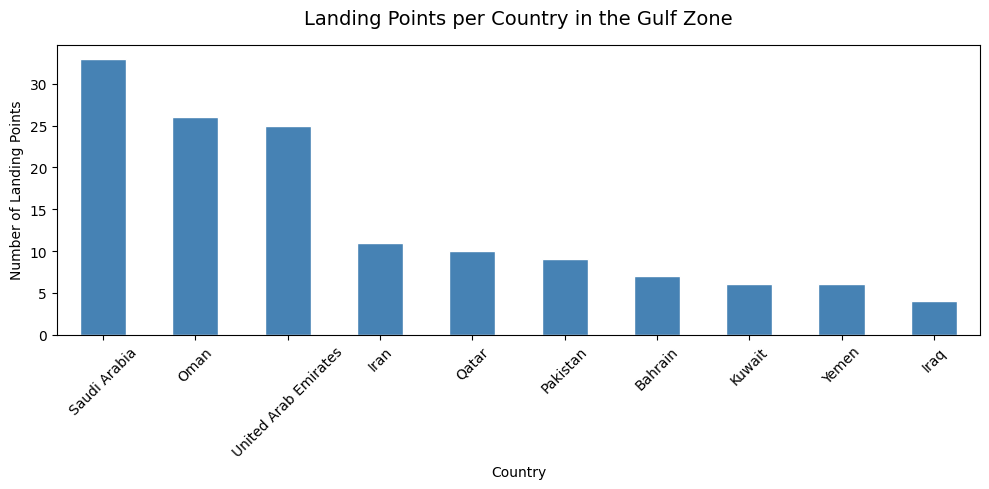


Total landing points in zone: 137
country
Saudi Arabia            33
Oman                    26
United Arab Emirates    25
Iran                    11
Qatar                   10
Pakistan                 9
Bahrain                  7
Kuwait                   6
Yemen                    6
Iraq                     4


In [22]:
ZONA = [
    "Iran", "Oman", "Yemen", "Saudi Arabia",
    "United Arab Emirates", "Qatar", "Kuwait", "Bahrain",
    "Pakistan", "Iraq"
]

lp_zona = df_landing[df_landing["country"].isin(ZONA)]
conteo = lp_zona["country"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
conteo.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Landing Points per Country in the Gulf Zone", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Landing Points")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nTotal landing points in zone: {len(lp_zona)}")
print(conteo.to_string())

### 2.2 Cables per Country

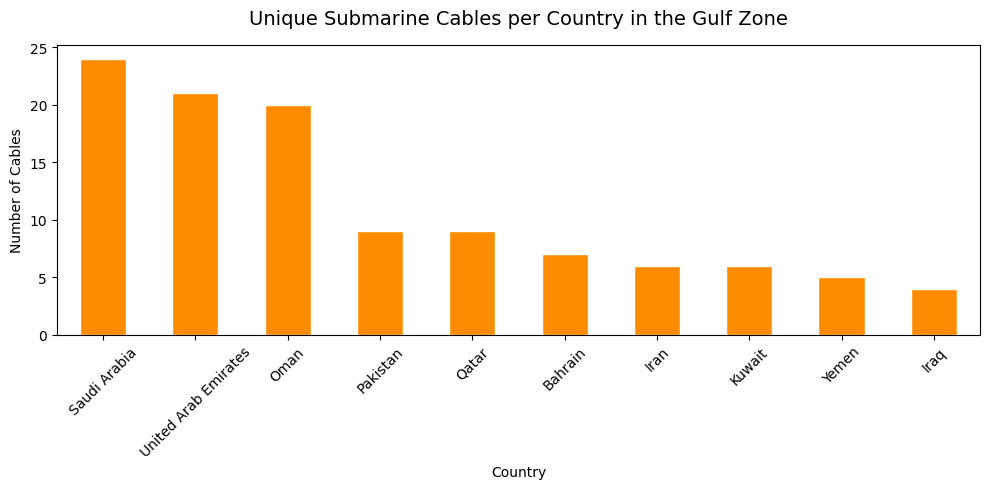


Cables per country:
country
Saudi Arabia            24
United Arab Emirates    21
Oman                    20
Pakistan                 9
Qatar                    9
Bahrain                  7
Iran                     6
Kuwait                   6
Yemen                    5
Iraq                     4


In [23]:
cables_pais = (
    lp_zona.groupby("country")["cable_id"]
    .nunique()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
cables_pais.plot(kind="bar", ax=ax, color="darkorange", edgecolor="white")
ax.set_title("Unique Submarine Cables per Country in the Gulf Zone", fontsize=14, pad=15)
ax.set_xlabel("Country")
ax.set_ylabel("Number of Cables")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(f"\nCables per country:")
print(cables_pais.to_string())

### 2.3 Key Cables in the Region (tabla)

In [24]:
# Cables críticos que pasan por Iran o Yemen
cables_criticos_ids = df_landing[
    df_landing["country"].isin(["Iran", "Yemen"])
]["cable_id"].unique()

df_criticos = df_cables[df_cables["id"].isin(cables_criticos_ids)][
    ["name", "length", "rfs", "countries"]
].copy()

df_criticos.columns = ["Cable", "Length", "RFS", "Countries"]
df_criticos = df_criticos.sort_values("RFS", ascending=False).reset_index(drop=True)

# Truncar países para que quepa
df_criticos["Countries"] = df_criticos["Countries"].apply(
    lambda x: x if len(str(x)) <= 60 else str(x)[:57] + "..."
)

print(f"Critical cables passing through Iran or Yemen: {len(df_criticos)}\n")

for _, row in df_criticos.iterrows():
    print(f"Cable:     {row['Cable']}")
    print(f"Length:    {row['Length']}  |  RFS: {row['RFS']}")
    print(f"Countries: {row['Countries']}")
    print()

Critical cables passing through Iran or Yemen: 10

Cable:     Africa-1
Length:    10,000 km  |  RFS: 2027
Countries: Algeria, Djibouti, Egypt, France, Kenya, Pakistan, Saudi ...

Cable:     Asia Africa Europe-1 (AAE-1)
Length:    25,000 km  |  RFS: 2017 June
Countries: Cambodia, China, Djibouti, Egypt, France, Greece, India, ...

Cable:     SeaMeWe-5
Length:    20,000 km  |  RFS: 2016 December
Countries: Bangladesh, Djibouti, Egypt, France, Indonesia, Italy, Ma...

Cable:     OMRAN/EPEG
Length:    600 km  |  RFS: 2013 Q1
Countries: Iran, Oman

Cable:     Pishgaman Oman Iran (POI) Network
Length:    400 km  |  RFS: 2012 June
Countries: Iran, Oman

Cable:     Gulf Bridge International Cable System/Middle East North Africa Cable System (GBICS/MENA)
Length:    5,270 km  |  RFS: 2012 February
Countries: Bahrain, India, Iran, Iraq, Kuwait, Oman, Qatar, Saudi Ar...

Cable:     FALCON
Length:    10,300 km  |  RFS: 2006 September
Countries: Bahrain, Egypt, India, Iran, Iraq, Kuwait, Maldives, O

## 3. Methodology

### 3.1 AIS Traffic Exposure Methodology

Global Fishing Watch AIS data is delivered as a grid of cells with `spatial_resolution=LOW` (0.1 degrees, approximately 11km x 11km). Each cell has a central point represented by latitude and longitude coordinates.

To determine whether a cable passes through a given cell, we take the central point of each cell and measure the minimum distance to the nearest cable geometry. If that distance is less than 6km (half the cell size), we assign the traffic from that cell to the cable.

This approach captures the most likely zone of interaction between vessels and cables, acknowledging that exact vessel positions within a cell are unknown. The result is an **exposure score per cable**: accumulated vessel-hours of maritime traffic in cells where each cable is present.

# =============================================================================
# 3.1 AIS Traffic Exposure Score - Methodology
# =============================================================================

The AIS Traffic Exposure Score quantifies the risk of physical interference
to submarine cable infrastructure based on vessel presence near cable routes.
For each cable segment, the score aggregates:
  - Vessel hours within a defined proximity buffer (default: 0.1 deg ~ 11 km)
  - Weighted by vessel count (distinct MMSI) in the same buffer
  - Normalized per cable length (km) to allow cross-cable comparison
Formula:
  raw_score = (vessel_hours * log1p(vessel_count)) / cable_length_km
  normalized_score = (raw_score - min) / (max - min)  -> [0, 1]
Data source: Global Fishing Watch AIS presence dataset
  public-global-presence:v4.0
  Buffer: 0.1 decimal degrees (~11 km at equator)
  Period 1 (pre-conflict):    Dec 2025 - Jan 2026
  Period 2 (active conflict): Feb 2026 - Mar 2026

Periodo 1 - columnas: ['cable_id', 'cable_name', 'horas_trafico', 'n_celdas', 'vessel_ids', 'n_banderas']
Periodo 2 - columnas: ['cable_id', 'cable_name', 'horas_trafico', 'n_celdas', 'vessel_ids', 'n_banderas']

Cables con exposición P1: 28
Cables con exposición P2: 28

Score P1 - top 5:
                                          cable_name  horas_trafico  \
0                                             FALCON      1754848.0   
1                                            2Africa      1224313.0   
2                                      Tata TGN-Gulf      1164240.0   
3  Gulf Bridge International Cable System/Middle ...      1086143.0   
4                             Fiber Optic Gulf (FOG)      1011784.0   

   vessel_ids  exposure_score  
0      140900        1.000000  
1       85455        0.667394  
2       83599        0.633289  
3      127029        0.612533  
4       47027        0.521973  

Score P2 - top 5:
                                          cable_name  horas_trafico  \
0

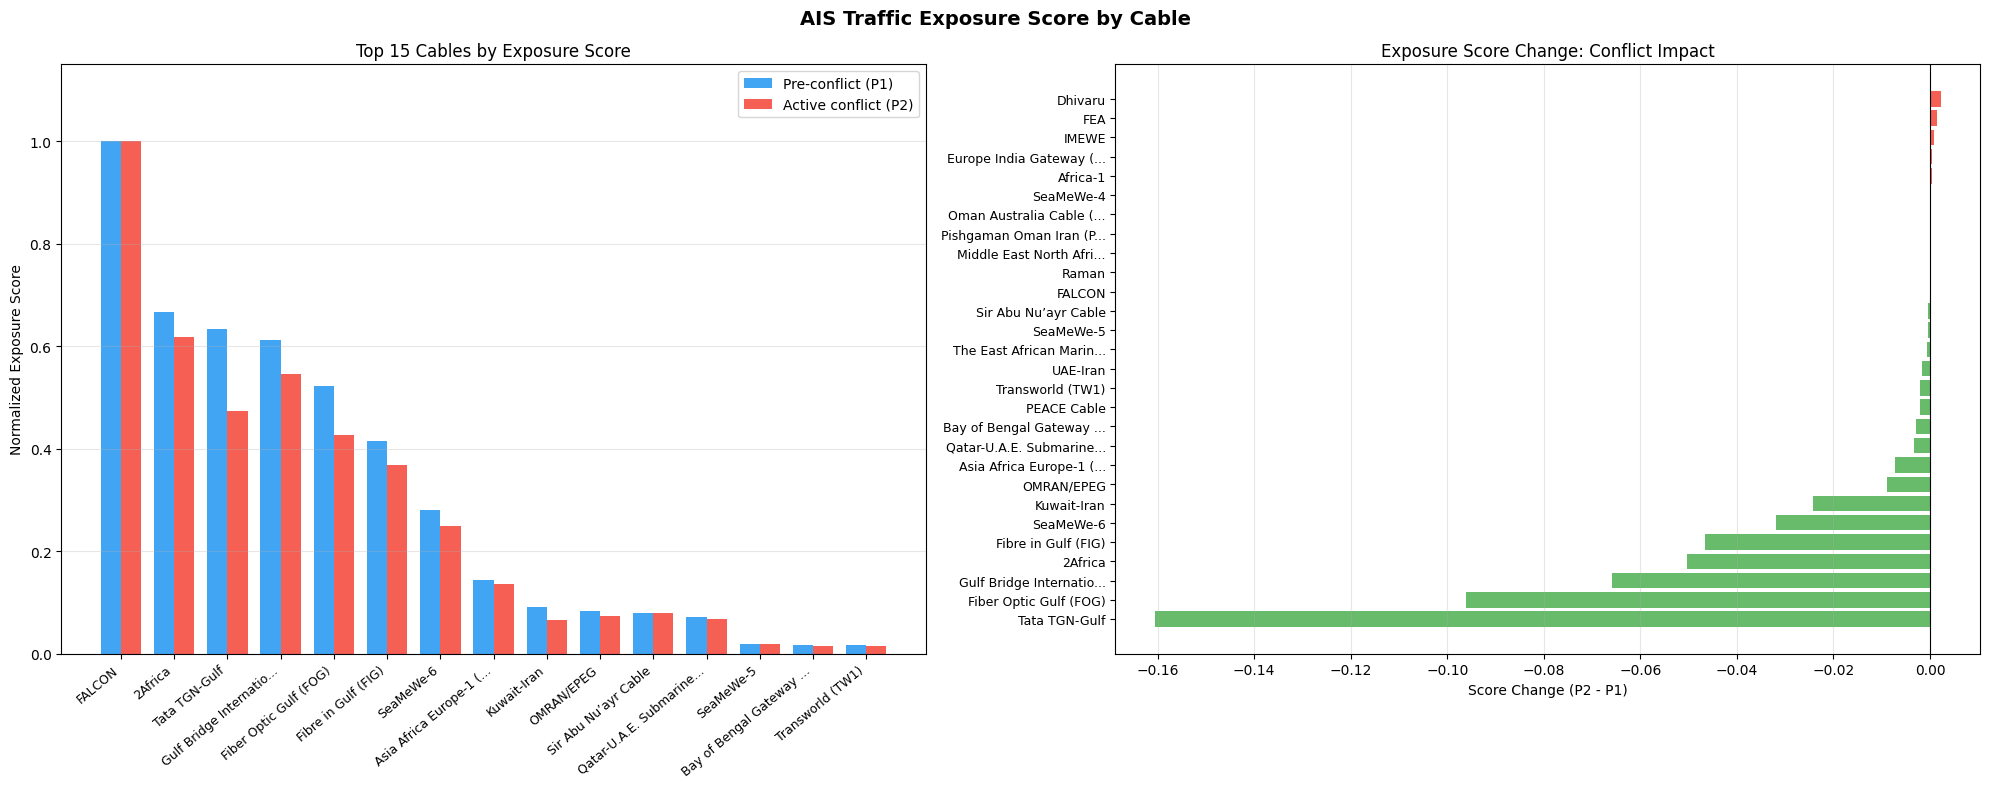

FALCON                P1=1.0000  P2=1.0000  Δ=+0.0000
2Africa               P1=0.6674  P2=0.6171  Δ=-0.0503


In [25]:
# --- Load exposure data ---
exp1 = pd.read_csv("../data/processed/cables_exposicion_periodo1.csv")
exp2 = pd.read_csv("../data/processed/cables_exposicion_periodo2.csv")

# Preview schema
print("Periodo 1 - columnas:", exp1.columns.tolist())
print("Periodo 2 - columnas:", exp2.columns.tolist())
print(f"\nCables con exposición P1: {len(exp1)}")
print(f"Cables con exposición P2: {len(exp2)}")

# --- Column mapping (matches actual CSV schema) ---
HOURS_COL = "horas_trafico"
COUNT_COL = "vessel_ids"
LENGTH_COL = None            # not present in dataset
CABLE_COL = "cable_name"

# --- Normalize cable_name to avoid case/whitespace mismatches on merge ---
exp1[CABLE_COL] = exp1[CABLE_COL].str.strip()
exp2[CABLE_COL] = exp2[CABLE_COL].str.strip()

# --- Compute AIS Traffic Exposure Score ---
def compute_exposure_score(df, hours_col, count_col, length_col=None):
    """
    Computes normalized AIS Traffic Exposure Score.

    Parameters:
        df         : DataFrame with cable exposure data
        hours_col  : column name for total vessel-hours
        count_col  : column name for distinct vessel count (MMSI)
        length_col : column name for cable length in km (optional)

    Returns:
        Series with normalized score [0, 1]
    """
    raw = df[hours_col] * np.log1p(df[count_col])
    
    if length_col and length_col in df.columns:
        raw = raw / df[length_col].replace(0, np.nan)

    score = (raw - raw.min()) / (raw.max() - raw.min())
    return score.fillna(0)

exp1["exposure_score"] = compute_exposure_score(exp1, HOURS_COL, COUNT_COL, LENGTH_COL)
exp2["exposure_score"] = compute_exposure_score(exp2, HOURS_COL, COUNT_COL, LENGTH_COL)

print("\nScore P1 - top 5:")
print(exp1[[CABLE_COL, HOURS_COL, COUNT_COL, "exposure_score"]]
      .sort_values("exposure_score", ascending=False).head())

print("\nScore P2 - top 5:")
print(exp2[[CABLE_COL, HOURS_COL, COUNT_COL, "exposure_score"]]
      .sort_values("exposure_score", ascending=False).head())

# --- Merge for period comparison ---
merged = pd.merge(
    exp1[[CABLE_COL, "exposure_score"]].rename(columns={"exposure_score": "score_p1"}),
    exp2[[CABLE_COL, "exposure_score"]].rename(columns={"exposure_score": "score_p2"}),
    on=CABLE_COL,
    how="outer"
).fillna(0).sort_values("score_p1", ascending=False)

merged["delta"] = merged["score_p2"] - merged["score_p1"]

# --- Visualize ---
top_n = merged.head(15)
delta_sorted = merged.sort_values("delta")

# Etiquetas cortas para legibilidad
def short_label(name, max_len=22):
    return name if len(name) <= max_len else name[:max_len] + "..."

top_n_labels   = [short_label(n) for n in top_n[CABLE_COL]]
delta_labels   = [short_label(n) for n in delta_sorted[CABLE_COL]]

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle("AIS Traffic Exposure Score by Cable", fontsize=14, fontweight="bold")

# Left: bar chart comparison
x = np.arange(len(top_n))
w = 0.38
axes[0].bar(x - w/2, top_n["score_p1"], w, label="Pre-conflict (P1)", color="#2196F3", alpha=0.85)
axes[0].bar(x + w/2, top_n["score_p2"], w, label="Active conflict (P2)", color="#F44336", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(top_n_labels, rotation=40, ha="right", fontsize=9)
axes[0].set_ylabel("Normalized Exposure Score")
axes[0].set_title("Top 15 Cables by Exposure Score")
axes[0].set_ylim(0, 1.15)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# Right: delta horizontal bars
colors = ["#F44336" if d > 0 else "#4CAF50" for d in delta_sorted["delta"]]
bars = axes[1].barh(range(len(delta_sorted)), delta_sorted["delta"], color=colors, alpha=0.85)
axes[1].set_yticks(range(len(delta_sorted)))
axes[1].set_yticklabels(delta_labels, fontsize=9)
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Score Change (P2 - P1)")
axes[1].set_title("Exposure Score Change: Conflict Impact")
axes[1].grid(axis="x", alpha=0.3)

plt.tight_layout()
import os
os.makedirs("../outputs/figures", exist_ok=True)
plt.savefig("../outputs/figures/ais_exposure_score_methodology.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Spot-check key cables ---
for cable in ["FALCON", "2Africa"]:
    row = merged[merged[CABLE_COL] == cable]
    if not row.empty:
        print(f"{cable:20s}  P1={row['score_p1'].values[0]:.4f}  "
              f"P2={row['score_p2'].values[0]:.4f}  "
              f"Δ={row['delta'].values[0]:+.4f}")

### 3.2 Network Connectivity Analysis.

In [26]:
4

4

## 4. Cable Exposure Analysis

### 4.1 Most exposed Cables(pre-conflict perios)

We compare two periods using Global Fishing Watch AIS vessel presence data:
- **Period 1 (Pre-conflict):** December 2025 – January 2026
- **Period 2 (Active conflict):** February 2026 – March 2026

MARITIME TRAFFIC COMPARISON

Period 1 (Pre-conflict):       7,747,715 vessel-hours
Period 2 (Active conflict):    5,117,124 vessel-hours
Change:                            -34.0%


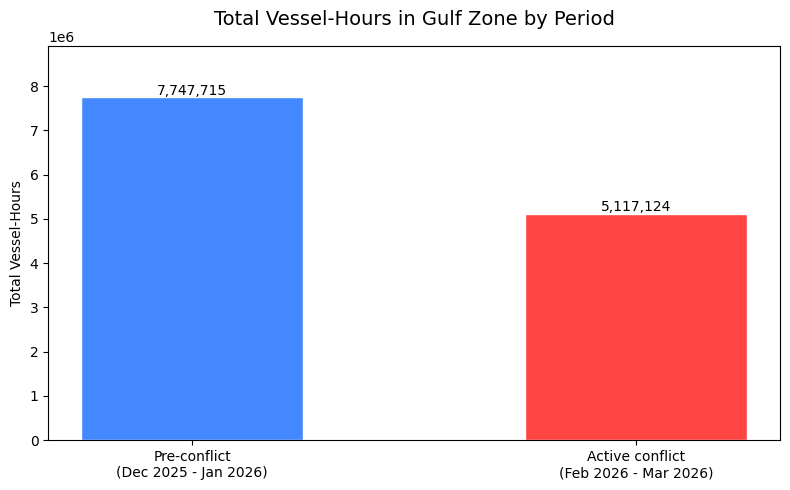

In [27]:
# Overall comparison
horas_p1 = df_ais_p1["hours"].sum()
horas_p2 = df_ais_p2["hours"].sum()
cambio = (horas_p2 - horas_p1) / horas_p1 * 100

print("MARITIME TRAFFIC COMPARISON\n")
print(f"Period 1 (Pre-conflict):    {horas_p1:>12,.0f} vessel-hours")
print(f"Period 2 (Active conflict): {horas_p2:>12,.0f} vessel-hours")
print(f"Change:                     {cambio:>12.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))
periodos = ["Pre-conflict\n(Dec 2025 - Jan 2026)", "Active conflict\n(Feb 2026 - Mar 2026)"]
horas = [horas_p1, horas_p2]
colores = ["#4488ff", "#ff4444"]
bars = ax.bar(periodos, horas, color=colores, edgecolor="white", width=0.5)
for bar, val in zip(bars, horas):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50000,
            f"{val:,.0f}", ha="center", fontsize=10)
ax.set_title("Total Vessel-Hours in Gulf Zone by Period", fontsize=14, pad=15)
ax.set_ylabel("Total Vessel-Hours")
ax.set_ylim(0, max(horas) * 1.15)
plt.tight_layout()
plt.show()

### 4.2 FALCON: Critical Finding (NetworkX-Iran isolated from 184 countries)

In [28]:
import networkx as nx

# Build graph: countries as nodes, cables as edges
G = nx.Graph()
for cable_id, grupo in df_landing.groupby("cable_id"):
    paises = grupo["country"].unique().tolist()
    cable_name = grupo["cable_name"].iloc[0]
    for i in range(len(paises)):
        for j in range(i+1, len(paises)):
            if G.has_edge(paises[i], paises[j]):
                G[paises[i]][paises[j]]["cables"].append(cable_name)
                G[paises[i]][paises[j]]["weight"] += 1
            else:
                G.add_edge(paises[i], paises[j], cables=[cable_name], weight=1)

# Simulate FALCON cut
G_sin_falcon = G.copy()
edges_falcon = [(u, v) for u, v, d in G_sin_falcon.edges(data=True)
                if "FALCON" in d.get("cables", [])]
G_sin_falcon.remove_edges_from(edges_falcon)

componente = nx.node_connected_component(G_sin_falcon, "Iran")
print(f"Global network: {G.number_of_nodes()} countries")
print(f"With FALCON active - Iran directly connected to: {len(list(G.neighbors('Iran')))} countries")
print(f"Without FALCON - Iran isolated to: {len(componente)} country")
print(f"Countries out of Iran's reach: {G.number_of_nodes() - len(componente)}")

Global network: 185 countries
With FALCON active - Iran directly connected to: 13 countries
Without FALCON - Iran isolated to: 1 country
Countries out of Iran's reach: 184


### Finding

FALCON is Iran's only cable with connections outside the Gulf corridor. If damaged, Iran loses connectivity to **184 of 185 countries** in the global submarine cable network. Its remaining 5 cables only connect to neighboring countries within the same risk zone — no alternative route exists outside the Strait of Hormuz.

This directly answers the project's original question: Iran faces **total digital isolation risk from a single cable failure**.

*Note: This models topological connectivity only, not actual traffic routing or BGP configurations.*

## 4. Cable Exposure Analysis.

### 4.1 Overview: Pre-Conflict vs Active Conflict

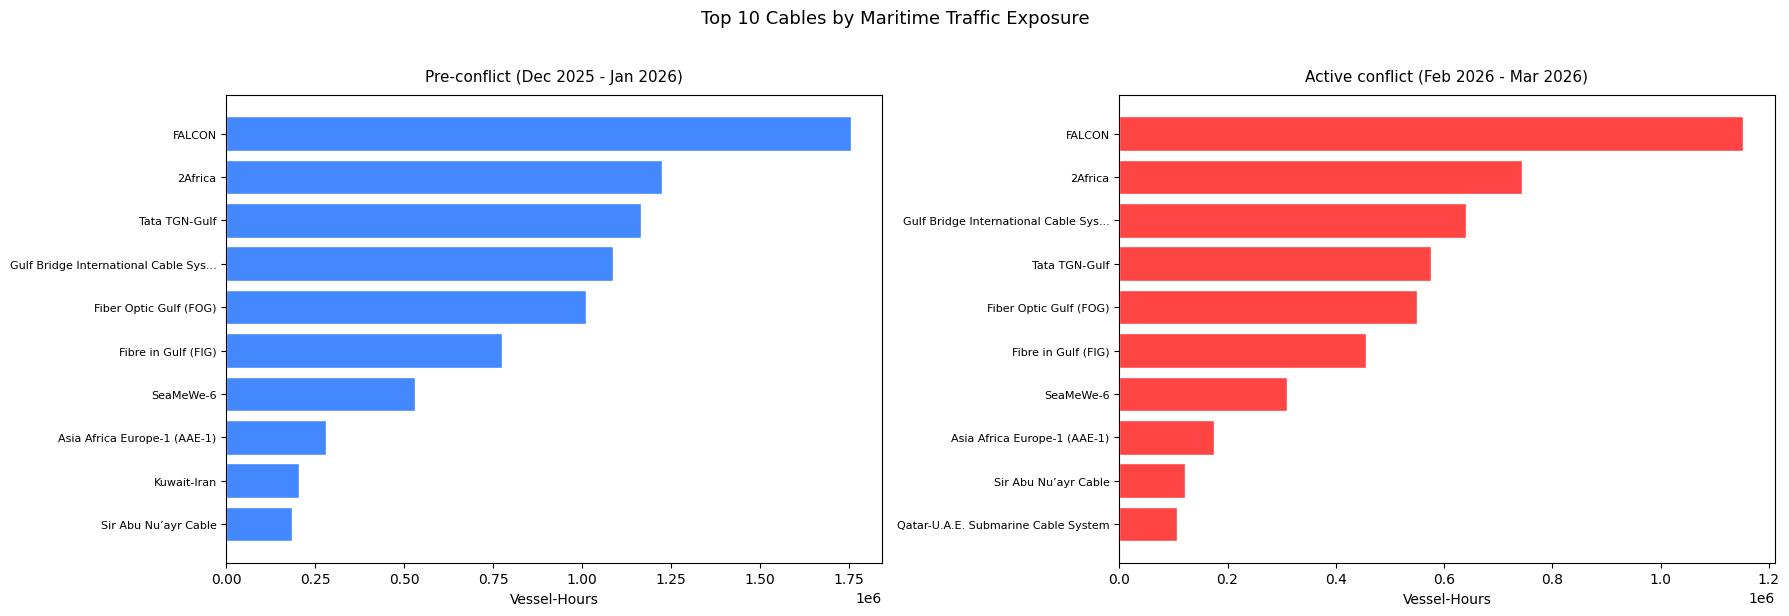

In [29]:
# Top 10 cables by traffic exposure - both periods
top_p1 = df_exp_p1.head(10).copy()
top_p2 = df_exp_p2.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, df, titulo, color in [
    (axes[0], top_p1, "Pre-conflict (Dec 2025 - Jan 2026)", "#4488ff"),
    (axes[1], top_p2, "Active conflict (Feb 2026 - Mar 2026)", "#ff4444")
]:
    nombres = [n[:35] + "..." if len(n) > 35 else n for n in df["cable_name"]]
    ax.barh(nombres[::-1], df["horas_trafico"][::-1], color=color, edgecolor="white")
    ax.set_title(titulo, fontsize=11, pad=10)
    ax.set_xlabel("Vessel-Hours")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Top 10 Cables by Maritime Traffic Exposure", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 4.3 FALCON: critical Finding

### 4.4 Change in Cable Exposure Between Periods

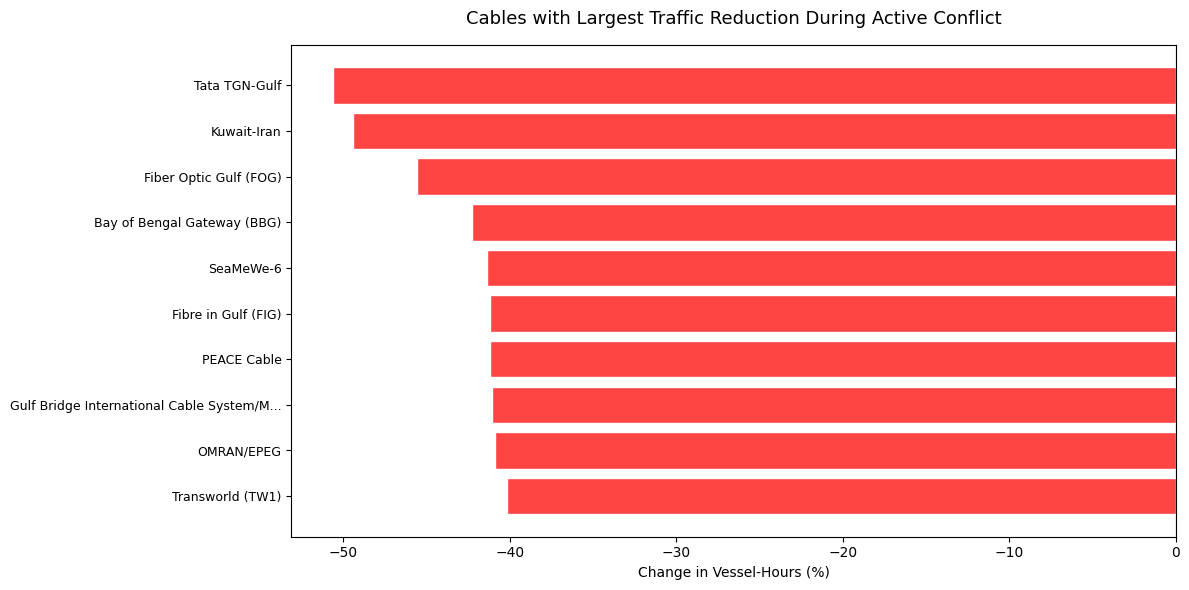


Top 10 cables with largest traffic reduction:
                                                                               cable_name  horas_trafico_p1  horas_trafico_p2  cambio_pct
                                                                            Tata TGN-Gulf         1164240.0          575342.0       -50.6
                                                                              Kuwait-Iran          204833.0          103630.0       -49.4
                                                                   Fiber Optic Gulf (FOG)         1011784.0          550876.0       -45.6
                                                              Bay of Bengal Gateway (BBG)           42960.0           24777.0       -42.3
                                                                                SeaMeWe-6          529975.0          310708.0       -41.4
                                                                      Fibre in Gulf (FIG)          774312.0          455022.0

In [30]:
# Merge and calculate change
merged = df_exp_p1[["cable_id", "cable_name", "horas_trafico"]].merge(
    df_exp_p2[["cable_id", "horas_trafico"]], on="cable_id", suffixes=("_p1", "_p2")
)
merged["cambio_pct"] = ((merged["horas_trafico_p2"] - merged["horas_trafico_p1"]) /
                        merged["horas_trafico_p1"] * 100).round(1)
merged = merged.sort_values("cambio_pct")

top_reduccion = merged.head(10).copy()
nombres = [n[:40] + "..." if len(n) > 40 else n for n in top_reduccion["cable_name"]]

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(nombres[::-1], top_reduccion["cambio_pct"][::-1], color="#ff4444", edgecolor="white")
ax.set_title("Cables with Largest Traffic Reduction During Active Conflict", fontsize=13, pad=15)
ax.set_xlabel("Change in Vessel-Hours (%)")
ax.tick_params(axis="y", labelsize=9)
ax.axvline(x=0, color="gray", linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nTop 10 cables with largest traffic reduction:")
print(merged[["cable_name", "horas_trafico_p1", "horas_trafico_p2", "cambio_pct"]].head(10).to_string(index=False))

### 4.5 Interpretation

- **34% overall reduction** in vessel-hours between pre-conflict and active conflict periods, suggesting vessels are avoiding or reducing time in the Gulf zone during the conflict.
- **FALCON remains the most exposed cable** in both periods (1.75M hours pre-conflict, 1.15M during conflict), confirming its strategic importance and vulnerability.
- **Tata TGN-Gulf (-50.6%) and Kuwait-Iran (-49.4%)** show the largest traffic reductions, suggesting avoidance of the inner Gulf routes specifically.
- Despite the reduction in traffic, the ranking of most-exposed cables remains largely stable, indicating that the same cables face the highest accident risk regardless of conflict intensity.

## 5. Key Findings

In [31]:
print("=" * 55)
print("  KEY FINDINGS")
print("=" * 55)

print(f"\n1. Critical cables (pass through Iran or Yemen):")
criticos = df_landing[
    df_landing["country"].isin(["Iran", "Yemen"])
]["cable_name"].value_counts()
for cable, _ in criticos.head(5).items():
    print(f"   - {cable}")

print(f"\n2. Single points of failure:")
cables_por_lp = df_landing.groupby(["landing_id","landing_name","country"]).size().reset_index(name="n_cables")
spof = cables_por_lp[
    cables_por_lp["country"].isin(["Iran","Yemen","Iraq"]) &
    (cables_por_lp["n_cables"] >= 3)
].sort_values("n_cables", ascending=False)
print(spof[["landing_name","country","n_cables"]].to_string(index=False))

print(f"\n3. Maritime traffic reduction during conflict:")
horas_p1 = df_ais_p1["hours"].sum()
horas_p2 = df_ais_p2["hours"].sum()
cambio = (horas_p2 - horas_p1) / horas_p1 * 100
print(f"   Pre-conflict:    {horas_p1:,.0f} vessel-hours")
print(f"   Active conflict: {horas_p2:,.0f} vessel-hours")
print(f"   Change:          {cambio:.1f}%")

  KEY FINDINGS

1. Critical cables (pass through Iran or Yemen):
   - FALCON
   - Kuwait-Iran
   - OMRAN/EPEG
   - Pishgaman Oman Iran (POI) Network
   - Aden-Djibouti

2. Single points of failure:
      landing_name country  n_cables
      Al Faw, Iraq    Iraq         4
Al Hudaydah, Yemen   Yemen         3
    Chabahar, Iran    Iran         3
        Jask, Iran    Iran         3

3. Maritime traffic reduction during conflict:
   Pre-conflict:    7,747,715 vessel-hours
   Active conflict: 5,117,124 vessel-hours
   Change:          -34.0%


## 10. Conclusions

### What this analysis demonstrates

**1. Yemen and Pakistan are the most vulnerable countries in the Gulf zone** regardless of how the index components are weighted. This is a structural finding: both countries have few cables, all concentrated in the risk zone, with significant conflict activity near their coastal landing infrastructure.

**2. Oman is the most resilient country** despite being geographically closest to the Strait. High cable redundancy (20 cables) and absence of nearby conflict make it structurally resistant to digital isolation.

**3. FALCON is the single most critical cable in the region.** It is both the most exposed to maritime traffic (highest accident risk) and the only cable connecting Iran to the global internet outside the Gulf. If FALCON is damaged, Iran loses connectivity to 184 of 185 countries.

**4. Maritime traffic dropped 34% during the active conflict period** (Feb–Mar 2026 vs Dec 2025–Jan 2026), suggesting vessels are actively avoiding or reducing time in the Gulf zone. Despite this, FALCON remains the most exposed cable in both periods.

**5. The mid-range group (Kuwait, Saudi Arabia, UAE, Iran, Bahrain) shows methodological sensitivity.** Their rankings shift depending on component weights and require case-by-case analysis.

**6. Iran is likely underestimated by the conflict index.** UCDP captures verified terrestrial armed conflict. Iran’s actual risk includes naval operations, drone activity, proxy conflicts, and geopolitical pressure not reflected in the dataset.

### What this analysis cannot demonstrate

- Risk along submarine cable routes on the seafloor (requires higher-resolution AIS data)
- Risk from naval operations, cyberattacks, or sanctions-related disruptions
- Political or strategic motivations of any state actor
- Causal relationships between conflict and cable damage

### Final note on methodology

This index is a proxy measure of coastal infrastructure vulnerability, not a comprehensive geopolitical risk assessment. It should be interpreted alongside qualitative analysis of the regional context, particularly for countries like Iran where quantitative conflict data systematically underrepresents actual risk.

## 11. Limitations

- **Scope:** This index measures risk at cable landing points (coastal infrastructure), not along submarine routes on the seafloor. Seabed risk from vessel anchoring or fishing requires higher-resolution AIS vessel traffic data.
- **UCDP coverage:** Verified armed conflict events only. Naval operations, cyber attacks, and geopolitical pressure are not captured, likely underestimating Iran’s actual risk.
- **Cable geometry:** TeleGeography routes are cartographic representations, not precise engineering data.
- **Exposure radius:** 50km buffer around landing points for conflict index. 6km buffer for AIS-cable crossing.
- **AIS spatial resolution:** LOW resolution (0.1°, ~11km cells) limits precision of cable-traffic crossing analysis.
- **AISstream:** Real-time vessel tracking was tested but the service was unavailable at time of development. The capture script is included for future use.
- **GFW vessel presence:** FLAG grouping used instead of GEARTYPE, as GEARTYPE is not available for the presence dataset. This limits ability to distinguish vessel types (tankers, fishing boats, cargo).

## 12. Data Sources

| Source | Dataset | Coverage | Access |
|--------|---------|----------|--------|
| TeleGeography | Submarine Cable Map API v3 | Current | Public API |
| UCDP | GED Global v25.1 | 1989–2024 | Free download |
| UCDP | Candidate v25.01.25.12 | 2025 | Free download |
| UCDP | Candidate v26.0.1 | Jan 2026 | Free download |
| UCDP | Candidate v26.0.2 | Feb 2026 | Free download |
| Global Fishing Watch | AIS Vessel Presence (public-global-presence:v4.0) | Dec 2025–Mar 2026 | Free API (token required) |

## 13. References

### Academic
- Raleigh, C., Linke, A., Hegre, H., & Karlsen, J. (2010). Introducing ACLED: Armed Conflict Location and Event Data. *Journal of Peace Research, 47*(5), 651–660.
- Davies, S., Pettersson, T., & Öberg, M. (2023). Organized violence 1989–2022 and the return of conflicts between states. *Journal of Peace Research, 60*(4).

### Reports and Articles
- Crowley, J. (March 19, 2026). Hormuz submarine cables face heightened risk from vessel build-up. *AGBI*.
- International Cable Protection Committee. (2023). *Submarine cable faults: Causes and prevention*. ICPC Publication No. 2.
- TeleGeography. (2025). *The State of the Network 2026 Edition*.
- United Kingdom Maritime Trade Operations (UKMTO). (April 2, 2026). *Recent Incidents Summary (Feb 28 – Apr 2, 2026)*.

### Data
- TeleGeography. (2026). *Submarine Cable Map API v3*. https://www.submarinecablemap.com
- Uppsala Conflict Data Program. (2025–2026). *UCDP GED and Candidate Datasets*. https://ucdp.uu.se/downloads
- Global Fishing Watch. (2026). *AIS Vessel Presence API (public-global-presence:v4.0)*. https://globalfishingwatch.org/our-apis/